<table>
<tr><td><img style="height: 150px;" src="images/geo_hydro1.jpg"></td>
<td bgcolor="#FFFFFF">
    <p style="font-size: xx-large; font-weight: 900; line-height: 100%">AG Dynamics of the Earth</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Juypter notebooks</p>
    <p style="font-size: large; color: rgba(0,0,0,0.5);">Georg Kaufmann</p>
    </td>
</tr>
</table>

----
# 04: Borehole data example

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

----
## Data set

Data file with borehole logs from the Council Grove gas reservoir in Southwest Kansas, USA.

Data are from the **ten wells**:
1. SHRIMPLIN
2. ALEXANDER D
3. SHANKLE
4. LUKE G U
5. KIMZEY A
6. CROSS H CATTLE
7. NOLAN
8. Recruit F9
9. NEWBY
10. CHURCHMAN BIBLE

----
## Labels

The reported **lithological facies** are:

Facies |Label| Name
:---: | :---: |:--:
1| SS   | Nonmarine sandstone
2| CSiS | Nonmarine coarse siltstone 
3| FSiS | Nonmarine fine siltstone 
4| SiSh | Marine siltstone and shale 
5| MS  | Mudstone (limestone)
6| WS  | Wackestone (limestone)
7| D   | Dolomite
8| PS  | Packstone-grainstone (limestone)
9| BS  | Phylloid-algal bafflestone (limestone)


This data is from the Council Grove gas reservoir in Southwest Kansas. The Panoma Council Grove Field is predominantly a carbonate gas reservoir encompassing 2700 square miles in Southwestern Kansas. This dataset is from nine wells (with 4149 examples), consisting of a set of seven predictor variables and a rock facies (class) for each example vector and validation (test) data (830 examples from two wells) having the same seven predictor variables in the feature vector. Facies are based on examination of cores from nine wells taken vertically at half-foot intervals. Predictor variables include five from wireline log measurements and two geologic constraining variables that are derived from geologic knowledge. These are essentially continuous variables sampled at a half-foot sample rate.

----
## Features

Five **geophysical properties** have been logged:
1. [gamma ray](http://petrowiki.org/Gamma_ray_logs) (GR)
2. [resistivity logging](http://petrowiki.org/Resistivity_and_spontaneous_%28SP%29_logging) (ILD_log10)
3. [photoelectric effect](http://www.glossary.oilfield.slb.com/en/Terms/p/photoelectric_effect.aspx) (PE) 
4. [neutron-density porosity difference](http://petrowiki.org/Neutron_porosity_logs) (DeltaPHI)
5. [average neutron-density porosity](http://petrowiki.org/Neutron_porosity_logs) (PHIND)

In addition, two **geological properties** have been defined:
6. nonmarine-marine indicator (NM_M)
7. relative position (RELPOS)
    
    

----
## Data pre-processing

Load the data with `pandas`:

In [2]:
filename = 'data/Boreholes_CouncilGroveGasReservoir.csv'
training_data = pd.read_csv(filename)
print(training_data.shape[0])
training_data.head()

4149


,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,1,1.000
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,1,0.979
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,1,0.957
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,1,0.936
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,1,0.915


We remove the well **SHANKLE** from the original data set and store it in a data frame
`blind_data` for later use ...

In [3]:
blind_data    = training_data[training_data['Well Name'] == 'SHANKLE']
training_data = training_data[training_data['Well Name'] != 'SHANKLE']
print(training_data.shape[0])
training_data.head()

3700


,Facies,Formation,Well Name,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
0,3,A1 SH,SHRIMPLIN,2793.0,77.45,0.664,9.9,11.915,4.6,1,1.000
1,3,A1 SH,SHRIMPLIN,2793.5,78.26,0.661,14.2,12.565,4.1,1,0.979
2,3,A1 SH,SHRIMPLIN,2794.0,79.05,0.658,14.8,13.050,3.6,1,0.957
3,3,A1 SH,SHRIMPLIN,2794.5,86.10,0.655,13.9,13.115,3.5,1,0.936
4,3,A1 SH,SHRIMPLIN,2795.0,74.58,0.647,13.5,13.300,3.4,1,0.915


Examine statistics of data. We find that the **PE** feature has missing values ...

In [4]:
training_data.describe()

,Facies,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
count,3700.000000,3700.000000,3700.000000,3700.000000,3700.000000,3700.000000,2783.000000,3700.000000,3700.000000
mean,4.615676,2908.853378,64.873649,0.663053,4.651677,12.892826,3.805693,1.540000,0.524125
std,2.475808,139.010855,30.817166,0.253863,5.109006,6.796219,0.894118,0.498465,0.287147
min,1.000000,2573.500000,10.149000,-0.025949,-21.832000,0.550000,0.200000,1.000000,0.000000
25%,2.000000,2818.500000,43.778250,0.502000,1.800000,8.350000,3.200000,1.000000,0.278000
50%,4.000000,2939.000000,64.817000,0.645613,4.400000,11.857500,3.600000,2.000000,0.531000
75%,7.000000,3015.125000,80.322500,0.823000,7.600000,15.750000,4.400000,2.000000,0.772000
max,9.000000,3138.000000,361.150000,1.800000,19.312000,84.400000,8.094000,2.000000,1.000000


We simply drop the entries with missing **PE** data:

In [5]:
PE_mask = training_data['PE'].notnull().values
training_data = training_data[PE_mask]
training_data.describe()

,Facies,Depth,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
count,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000
mean,4.558390,2873.456522,66.249445,0.644637,3.754963,13.118929,3.805693,1.523895,0.523057
std,2.515249,138.349383,31.610849,0.241922,5.045916,7.389665,0.894118,0.499518,0.287499
min,1.000000,2573.500000,13.250000,-0.025949,-21.832000,0.550000,0.200000,1.000000,0.010000
25%,2.000000,2767.500000,46.081500,0.497000,1.300000,8.165000,3.200000,1.000000,0.276500
50%,4.000000,2895.000000,65.541000,0.627000,3.581000,11.900000,3.600000,2.000000,0.529000
75%,7.000000,2987.000000,80.714000,0.812323,6.500000,16.144000,4.400000,2.000000,0.771500
max,9.000000,3122.500000,361.150000,1.480000,18.500000,84.400000,8.094000,2.000000,1.000000


## `enumerate` excursion ...

In [ ]:
values = ["a", "b", "c"]
for value in values:
    print(value)
i = 0
for value in values:
    print(i,value)
    i += 1
for j,value in enumerate(values):
    print(j,value)

## Statistics of data set

In [8]:
# 1=sandstone  2=c_siltstone   3=f_siltstone 
# 4=marine_silt_shale 5=mudstone 6=wackestone 7=dolomite
# 8=packstone 9=bafflestone
facies_colors = ['#F4D03F', '#F5B041','#DC7633','#6E2C00',
       '#1B4F72','#2E86C1', '#AED6F1', '#A569BD', '#196F3D']

facies_labels = ['SS', 'CSiS', 'FSiS', 'SiSh', 'MS',
                 'WS', 'D','PS', 'BS']

First, uni-variate histograms for all seven features:

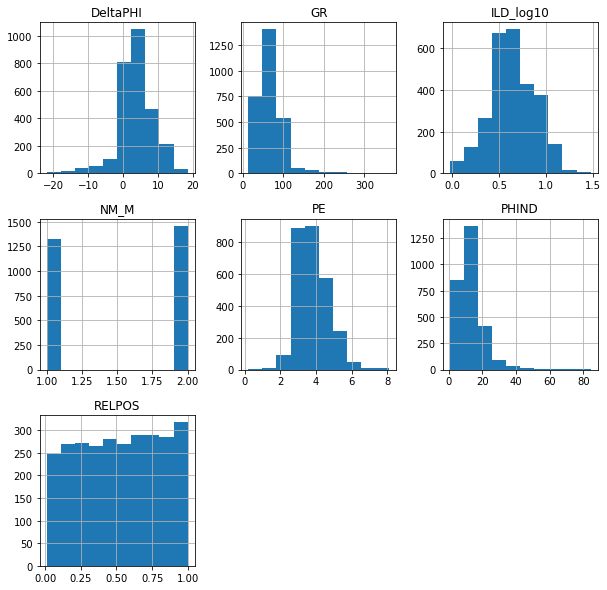

In [6]:
training_data[['GR','ILD_log10','DeltaPHI','PHIND','PE','NM_M','RELPOS']].hist(figsize=(10, 10))
plt.show()

Second, a heat map correlating pairs of features:

In [ ]:
corrmat = training_data[['GR','ILD_log10','DeltaPHI','PHIND','PE','NM_M','RELPOS']].corr()
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(corrmat, annot=True, ax=ax)
plt.show()

Third, a cross correlation matrix:

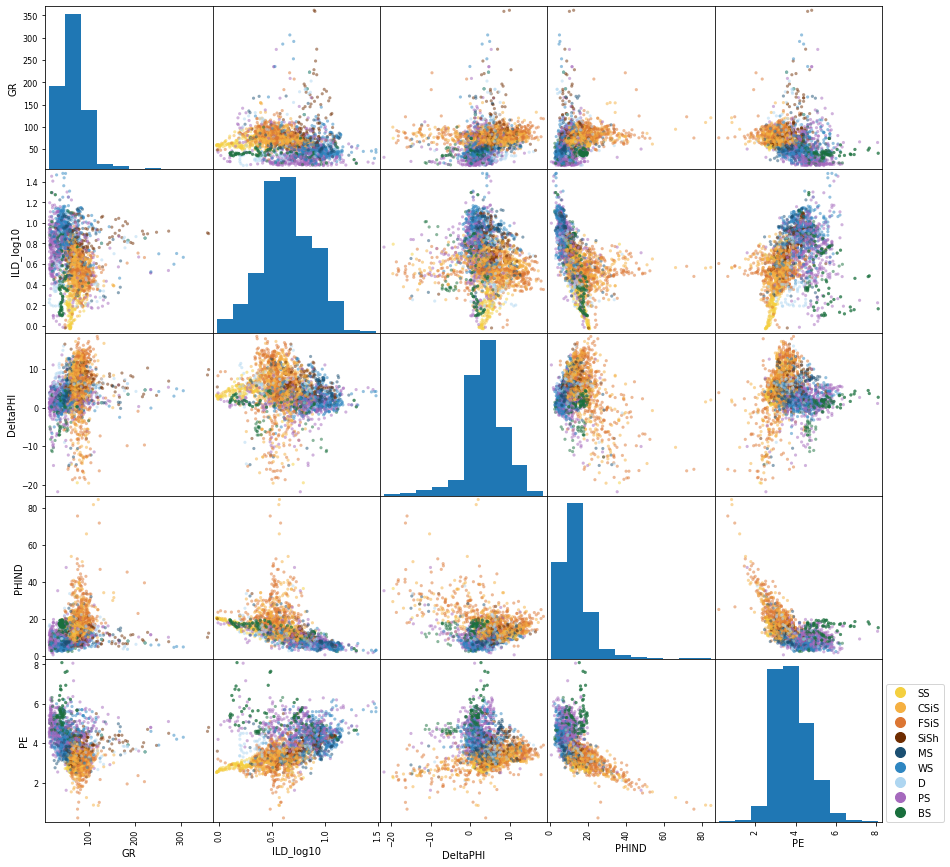

In [9]:
cmap_bold = ListedColormap(facies_colors)
x=pd.plotting.scatter_matrix(training_data[['GR','ILD_log10','DeltaPHI','PHIND','PE']],
#x=pd.plotting.scatter_matrix(training_data[['GR','ILD_log10','DeltaPHI','PHIND','PE','NM_M','RELPOS']],
                           marker='o',s=10,c=training_data['Facies'],cmap=cmap_bold, figsize=(15, 15))

handles = [plt.plot([],[],color=facies_colors[i], ls="", marker="o", \
                    markersize=10)[0] for i in range(len(facies_colors))]
labels=facies_labels
plt.legend(handles, labels, loc=(1.02,0))

## Plot well logs

In [10]:
def make_facies_log_plot(logs, facies_colors):
    #make sure logs are sorted by depth
    logs = logs.sort_values(by='Depth')
    cmap_facies = colors.ListedColormap(
            facies_colors[0:len(facies_colors)], 'indexed')
    
    ztop=logs.Depth.min(); zbot=logs.Depth.max()
    
    cluster=np.repeat(np.expand_dims(logs['Facies'].values,1), 100, 1)
    
    f, ax = plt.subplots(nrows=1, ncols=6, figsize=(8, 12))
    ax[0].plot(logs.GR, logs.Depth, '-g')
    ax[1].plot(logs.ILD_log10, logs.Depth, '-')
    ax[2].plot(logs.DeltaPHI, logs.Depth, '-', color='0.5')
    ax[3].plot(logs.PHIND, logs.Depth, '-', color='r')
    ax[4].plot(logs.PE, logs.Depth, '-', color='black')
    im=ax[5].imshow(cluster, interpolation='none', aspect='auto',
                    cmap=cmap_facies,vmin=1,vmax=9)
    
    divider = make_axes_locatable(ax[5])
    cax = divider.append_axes("right", size="20%", pad=0.25)
    cbar=plt.colorbar(im, cax=cax)
    cbar.set_label((17*' ').join([' SS ', 'CSiS', 'FSiS', 
                                'SiSh', ' MS ', ' WS ', ' D  ', 
                                ' PS ', ' BS ']))
    cbar.set_ticks(range(0,1)); cbar.set_ticklabels('')
    
    for i in range(len(ax)-1):
        ax[i].set_ylim(ztop,zbot)
        ax[i].invert_yaxis()
        ax[i].grid()
        ax[i].locator_params(axis='x', nbins=3)
    
    ax[0].set_ylabel('Depth [m]')
    ax[0].set_xlabel("GR")
    ax[0].set_xlim(logs.GR.min(),logs.GR.max())
    ax[1].set_xlabel("ILD_log10")
    ax[1].set_xlim(logs.ILD_log10.min(),logs.ILD_log10.max())
    ax[2].set_xlabel("DeltaPHI")
    ax[2].set_xlim(logs.DeltaPHI.min(),logs.DeltaPHI.max())
    ax[3].set_xlabel("PHIND")
    ax[3].set_xlim(logs.PHIND.min(),logs.PHIND.max())
    ax[4].set_xlabel("PE")
    ax[4].set_xlim(logs.PE.min(),logs.PE.max())
    ax[5].set_xlabel('Facies')
    
    ax[1].set_yticklabels([]); ax[2].set_yticklabels([]); ax[3].set_yticklabels([])
    ax[4].set_yticklabels([]); ax[5].set_yticklabels([])
    ax[5].set_xticklabels([])
    f.suptitle('Well: %s'%logs.iloc[0]['Well Name'], fontsize=14,y=0.94)

In [11]:
def compare_facies_plot(logs, compadre, facies_colors):
    #make sure logs are sorted by depth
    logs = logs.sort_values(by='Depth')
    cmap_facies = colors.ListedColormap(
            facies_colors[0:len(facies_colors)], 'indexed')
    
    ztop=logs.Depth.min(); zbot=logs.Depth.max()
    
    cluster1 = np.repeat(np.expand_dims(logs['Facies'].values,1), 100, 1)
    cluster2 = np.repeat(np.expand_dims(logs[compadre].values,1), 100, 1)
    
    f, ax = plt.subplots(nrows=1, ncols=7, figsize=(9, 12))
    ax[0].plot(logs.GR, logs.Depth, '-g')
    ax[1].plot(logs.ILD_log10, logs.Depth, '-')
    ax[2].plot(logs.DeltaPHI, logs.Depth, '-', color='0.5')
    ax[3].plot(logs.PHIND, logs.Depth, '-', color='r')
    ax[4].plot(logs.PE, logs.Depth, '-', color='black')
    im1 = ax[5].imshow(cluster1, interpolation='none', aspect='auto',
                    cmap=cmap_facies,vmin=1,vmax=9)
    im2 = ax[6].imshow(cluster2, interpolation='none', aspect='auto',
                    cmap=cmap_facies,vmin=1,vmax=9)
    
    divider = make_axes_locatable(ax[6])
    cax = divider.append_axes("right", size="20%", pad=0.05)
    cbar=plt.colorbar(im2, cax=cax)
    cbar.set_label((17*' ').join([' SS ', 'CSiS', 'FSiS', 
                                'SiSh', ' MS ', ' WS ', ' D  ', 
                                ' PS ', ' BS ']))
    cbar.set_ticks(range(0,1)); cbar.set_ticklabels('')
    
    for i in range(len(ax)-2):
        ax[i].set_ylim(ztop,zbot)
        ax[i].invert_yaxis()
        ax[i].grid()
        ax[i].locator_params(axis='x', nbins=3)
    
    ax[0].set_xlabel("GR")
    ax[0].set_xlim(logs.GR.min(),logs.GR.max())
    ax[1].set_xlabel("ILD_log10")
    ax[1].set_xlim(logs.ILD_log10.min(),logs.ILD_log10.max())
    ax[2].set_xlabel("DeltaPHI")
    ax[2].set_xlim(logs.DeltaPHI.min(),logs.DeltaPHI.max())
    ax[3].set_xlabel("PHIND")
    ax[3].set_xlim(logs.PHIND.min(),logs.PHIND.max())
    ax[4].set_xlabel("PE")
    ax[4].set_xlim(logs.PE.min(),logs.PE.max())
    ax[5].set_xlabel('Facies')
    ax[6].set_xlabel(compadre)
    
    ax[1].set_yticklabels([]); ax[2].set_yticklabels([]); ax[3].set_yticklabels([])
    ax[4].set_yticklabels([]); ax[5].set_yticklabels([]); ax[6].set_yticklabels([])
    ax[5].set_xticklabels([])
    ax[6].set_xticklabels([])
    f.suptitle('Well: %s'%logs.iloc[0]['Well Name'], fontsize=14,y=0.94)

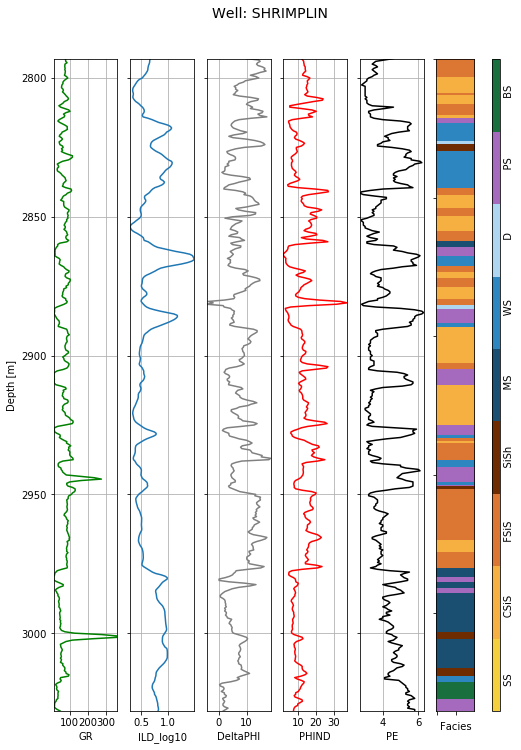

In [12]:
make_facies_log_plot(
    training_data[training_data['Well Name'] == 'SHRIMPLIN'],
    facies_colors)

In [ ]:
make_facies_log_plot(
    training_data[training_data['Well Name'] == 'LUKE G U'],
    facies_colors)

----
## Modelling

We first extract the **features** and the **labels** from the training data.

In [22]:
training_data['Well Name'].unique()

array(['SHRIMPLIN', 'LUKE G U', 'CROSS H CATTLE', 'NOLAN', 'Recruit F9',
       'NEWBY', 'CHURCHMAN BIBLE'], dtype=object)

In [31]:
y = training_data['Facies'].values
#X = training_data.drop(['Formation', 'Well Name', 'Depth','Facies'], axis=1)
X = training_data[['GR','ILD_log10','DeltaPHI','PHIND','PE','NM_M','RELPOS']]

In [32]:
print(X.shape)
print(y.shape)
X.describe()

(2783, 7)
(2783,)


,GR,ILD_log10,DeltaPHI,PHIND,PE,NM_M,RELPOS
count,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000,2783.000000
mean,66.249445,0.644637,3.754963,13.118929,3.805693,1.523895,0.523057
std,31.610849,0.241922,5.045916,7.389665,0.894118,0.499518,0.287499
min,13.250000,-0.025949,-21.832000,0.550000,0.200000,1.000000,0.010000
25%,46.081500,0.497000,1.300000,8.165000,3.200000,1.000000,0.276500
50%,65.541000,0.627000,3.581000,11.900000,3.600000,2.000000,0.529000
75%,80.714000,0.812323,6.500000,16.144000,4.400000,2.000000,0.771500
max,361.150000,1.480000,18.500000,84.400000,8.094000,2.000000,1.000000


We then scale the features with `StandardScaler`, and split them into **train** and 
**test** data:

In [33]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler().fit(X)
print(scaler)
X = scaler.transform(X)

StandardScaler(copy=True, with_mean=True, with_std=True)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

----
### Natural Neighbors

In [35]:
from sklearn import neighbors
clf = neighbors.KNeighborsClassifier(n_neighbors=1)
clf.fit(X_train, y_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=None, n_neighbors=1, p=2,
                     weights='uniform')

In [36]:
print ("%s %10.2f %1s" % ('Score for train data: ',round(clf.score(X_train,y_train)*100,2),'%'))
print ("%s %10.2f %1s" % ('Score for test data:  ',round(clf.score(X_test,y_test)*100,2),'%'))

Score for train data:       99.73 %
Score for test data:        72.71 %


In [37]:
y_blind = blind_data['Facies'].values
X_blind = blind_data[['GR','ILD_log10','DeltaPHI','PHIND','PE','NM_M','RELPOS']]
X_blind = scaler.transform(X_blind)

y_pred = clf.predict(X_blind)
blind_data['Prediction'] = y_pred
#blind_data.head()

In [38]:
print ("%s %10.2f %1s" % ('Score for blind data:  ',round(clf.score(X_blind,y_blind)*100,2),'%'))

Score for blind data:        39.64 %


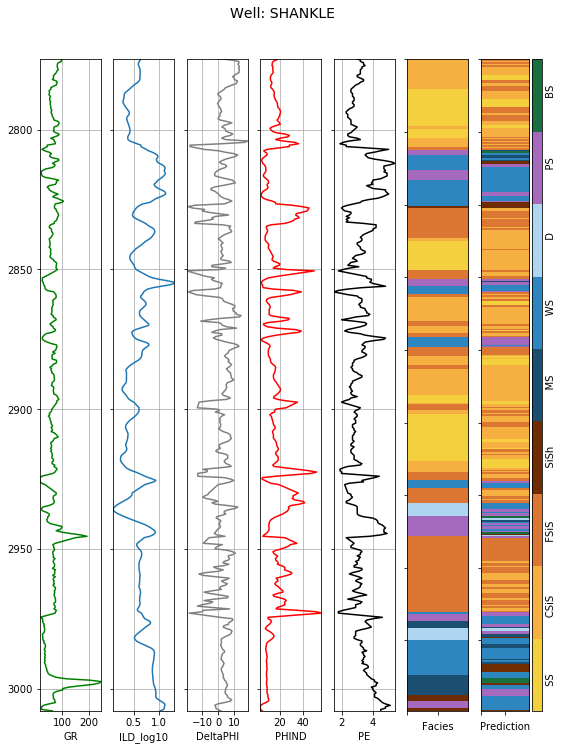

In [39]:
compare_facies_plot(blind_data, 'Prediction', facies_colors)

----
### Support-vector machine

In [43]:
from sklearn import svm
clf = svm.SVC(gamma='auto')
#clf = svm.SVC(C=10, gamma=1) 
clf.fit(X_train,y_train)

SVC(C=1.0, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='auto', kernel='rbf',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [44]:
print ("%s %10.1f %1s" % ('Score for train data: ',round(clf.score(X_train,y_train)*100,1),'%'))
print ("%s %10.1f %1s" % ('Score for test data:  ',round(clf.score(X_test,y_test)*100,1),'%'))

Score for train data:        67.2 %
Score for test data:         58.5 %


In [45]:
y_blind = blind_data['Facies'].values
X_blind = blind_data[['GR','ILD_log10','DeltaPHI','PHIND','PE','NM_M','RELPOS']]
X_blind = scaler.transform(X_blind)

In [46]:
y_pred = clf.predict(X_blind)
blind_data['Prediction'] = y_pred
#blind_data.head()

In [47]:
print ("%s %10.1f %1s" % ('Score for blind data:  ',round(clf.score(X_blind,y_blind)*100,1),'%'))

Score for blind data:         45.9 %


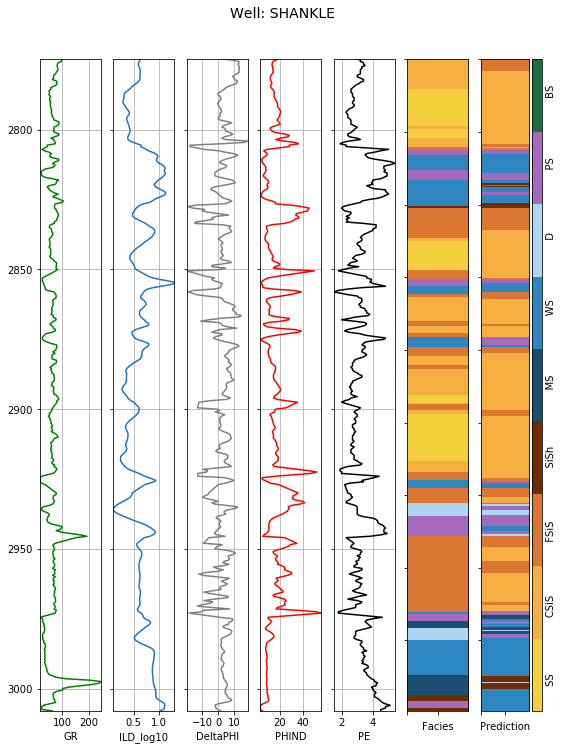

In [48]:
compare_facies_plot(blind_data, 'Prediction', facies_colors)

## Fine-tune support vector machine

In [49]:
from sklearn.metrics import confusion_matrix

def accuracy(conf):
    total_correct = 0.
    nb_classes = conf.shape[0]
    for i in np.arange(0,nb_classes):
        total_correct += conf[i][i]
    acc = total_correct/sum(sum(conf))
    return acc

We will consider two parameters.  The parameter `C` is a regularization factor, and tells the classifier how much we want to avoid misclassifying training examples.  A large value of C will try to correctly classify more examples from the training set, but if `C` is too large  it may 'overfit' the data and fail to generalize when classifying new data. If `C` is too small then the model will not be good at fitting outliers and will have a large error on the training set.

The SVM learning algorithm uses a kernel function to compute the distance between feature vectors.  Many kernel functions exist, but in this case we are using the radial basis function `rbf` kernel (the default).  The `gamma` parameter describes the size of the radial basis functions, which is how far away two vectors in the feature space need to be to be considered close.

In [50]:
C_range     = np.array([.01, 1, 5, 10, 20, 50, 100, 1000, 5000, 10000])
gamma_range = np.array([0.0001, 0.001, 0.01, 0.1, 1, 10])

#C_range     = np.array([.01, 1])
#gamma_range = np.array([0.0001, 0.001])

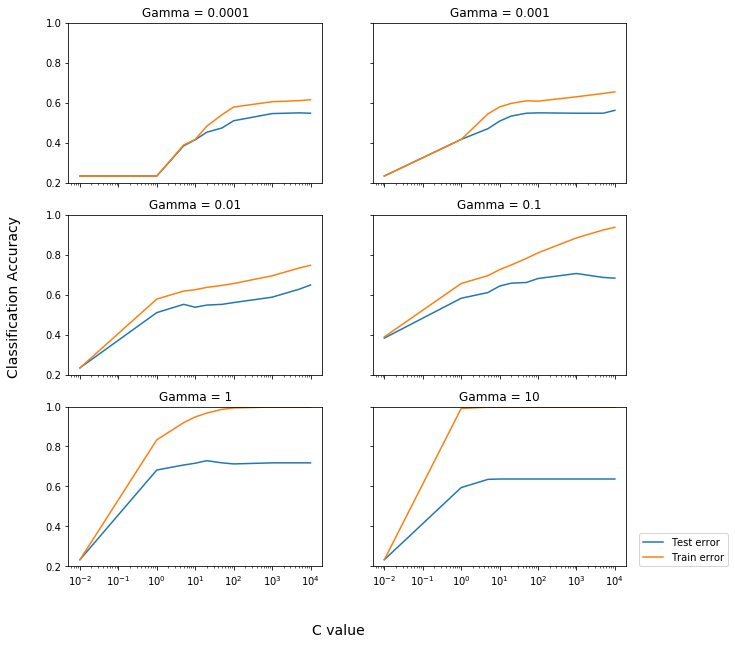

In [51]:
fig, axes = plt.subplots(3, 2, sharex='col', sharey='row',figsize=(10,10))
iplot = 0
for i in range(len(gamma_range)):
    test_errors = np.zeros(C_range.shape)
    train_errors = np.zeros(C_range.shape)
    row = int(iplot / 2)
    column = int(iplot % 2)
    for j in range(len(C_range)):
        #print (i,j)
        clf = svm.SVC(C=C_range[j], gamma=gamma_range[i]) 
        clf.fit(X_train,y_train)
        
        train_conf = confusion_matrix(y_train, clf.predict(X_train))
        test_conf = confusion_matrix(y_test, clf.predict(X_test))

        train_errors[j] = accuracy(train_conf)
        test_errors[j] = accuracy(test_conf)
        
    ax = axes[row, column]
    ax.set_ylim([0.2,1])
    ax.set_title('Gamma = %g'%gamma_range[i])
    ax.semilogx(C_range, test_errors, label='Test error')
    ax.semilogx(C_range, train_errors, label='Train error')
    iplot += 1
ax.legend(bbox_to_anchor=(1.05, 0), loc='lower left', borderaxespad=0.)
fig.text(0.5, 0.03, 'C value', ha='center',fontsize=14)
fig.text(0.04, 0.5, 'Classification Accuracy', va='center',rotation='vertical', fontsize=14)
plt.show()

In the parameter range searched, the test data yield a best value for
$C=10.0$ and $\gamma=1.0$.

Use for second SVC run:

In [52]:
clf = svm.SVC(C=10, gamma=1) 
clf.fit(X_train,y_train)
print ("%s %10.1f %1s" % ('Score for train data: ',round(clf.score(X_train,y_train)*100,1),'%'))
print ("%s %10.1f %1s" % ('Score for test data:  ',round(clf.score(X_test,y_test)*100,1),'%'))

y_blind = blind_data['Facies'].values
X_blind = blind_data[['GR','ILD_log10','DeltaPHI','PHIND','PE','NM_M','RELPOS']]
X_blind = scaler.transform(X_blind)
y_pred = clf.predict(X_blind)
blind_data['Prediction'] = y_pred
print ("%s %10.1f %1s" % ('Score for blind data: ',round(clf.score(X_blind,y_blind)*100,1),'%'))

Score for train data:        94.8 %
Score for test data:         71.6 %
Score for blind data:        41.4 %


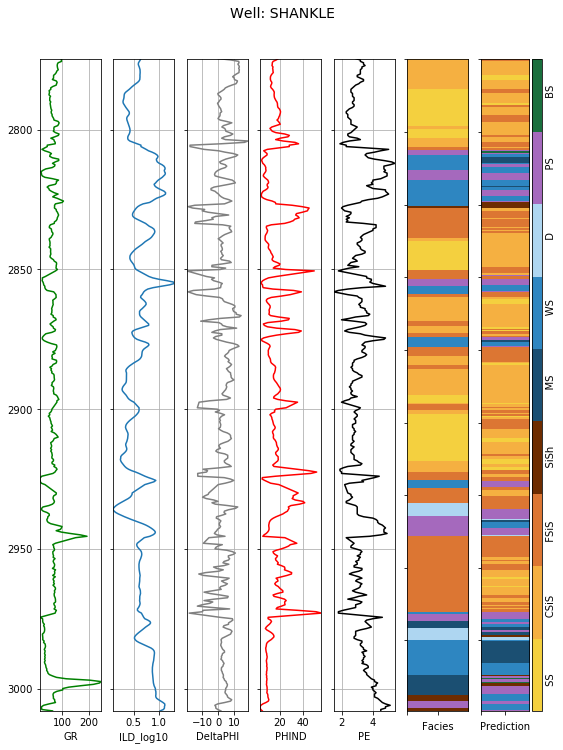

In [53]:
compare_facies_plot(blind_data, 'Prediction', facies_colors)

... done